<a href="https://colab.research.google.com/github/romulo-souza/Deep_Learning/blob/main/CNNs/MNIST/CNN_Generica_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prática CNN simples - Os dados utilizados são imagens do dataset Modified National Institute of Standards and Technology (MNIST), que contém 60000 imagens para treinamento e 10000 imagens para teste de **dígitos manuscritos**. O conjunto de dados inclui imagens em escala de cinza de resolução 28x28 pixels

##Biblioteca Keras: Facilita a construção e o treinamento de modelos de Deep Learning

* Dataset MNIST (proveniente da própria biblioteca Keras)

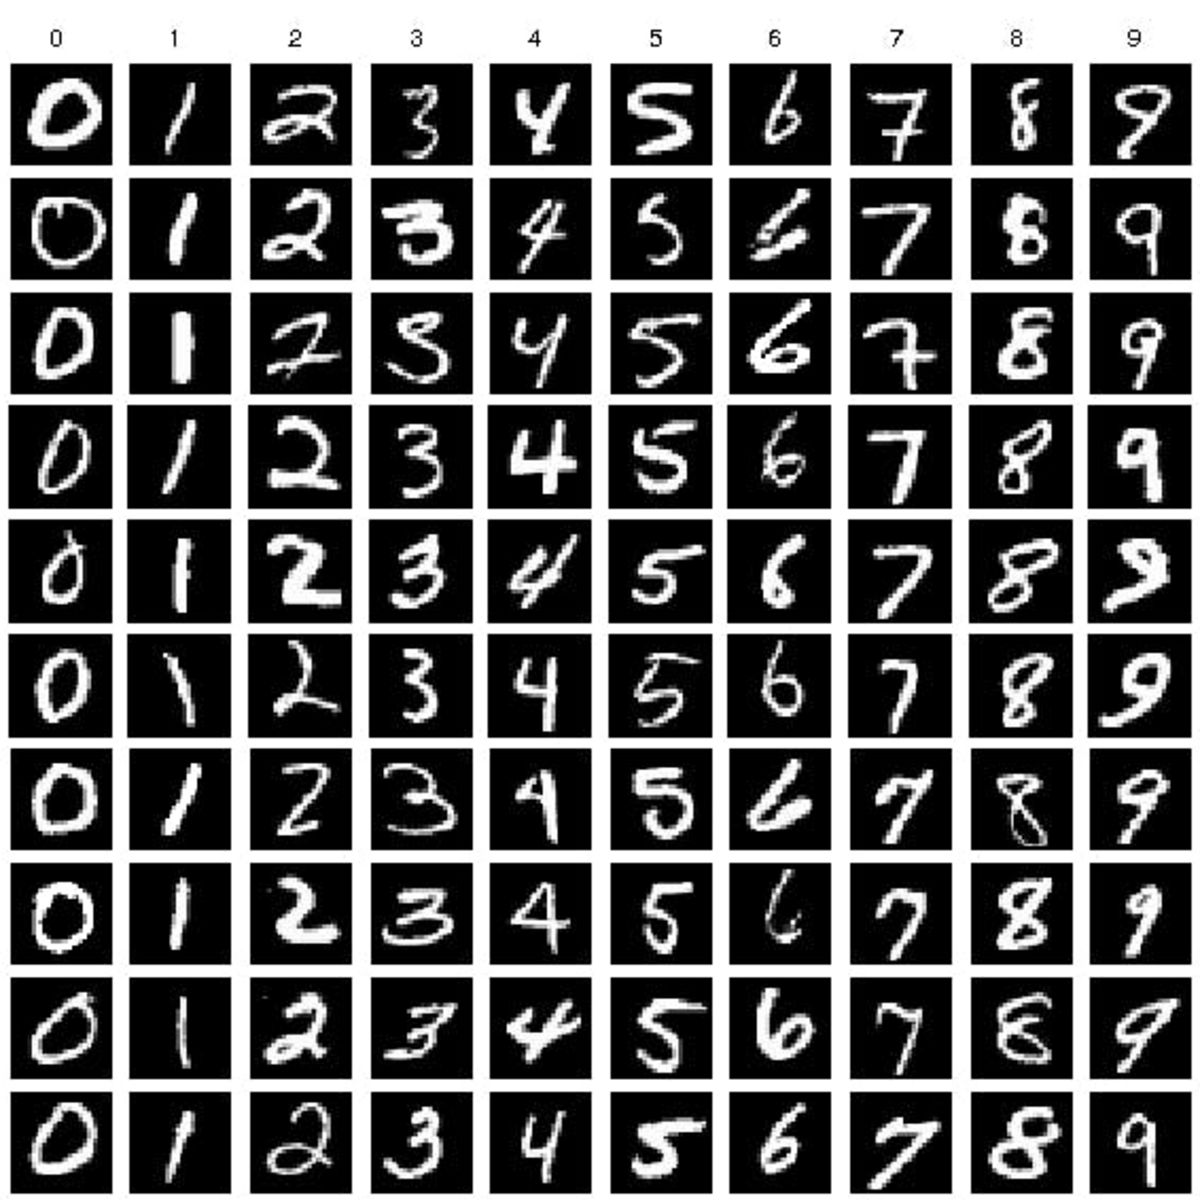

### **1 - Carregando as bibliotecas**

In [1]:
import keras
from keras import datasets, models, layers, utils, backend
from keras.callbacks import EarlyStopping, ModelCheckpoint
import cv2, random, os
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(100) # Define a semente do NumPy para gerar números aleatórios reproduzíveis
random.seed(100) # Define a semente do gerador de números aleatórios nativo do Python
utils.set_random_seed(100) # Define sementes para componentes aleatórios do Keras/TensorFlow, ajudando na reprodutibilidade dos resultados
#tf.random.set_seed(10) # Define a semente para o TensorFlow
os.environ['PYTHONHASHSEED'] = str(100) # Define a semente do hash do Python, ajudando na reprodutibilidade da ordem de estruturas internas baseadas em hash

### **2 - Formatando os dados(imagens) de entrada**




In [2]:
backend.set_image_data_format('channels_last') # Forçar os dados de entrada a ficarem no formato exigido pela CNN. Diz ao Keras como os tensores de imagem devem ser organizados na memória

### **3 - Carregamento dos dados de treinamento e validação**
* X: Dados(imagens/pixels)
* Y: Rótulos (resposta certa de cada imagem)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


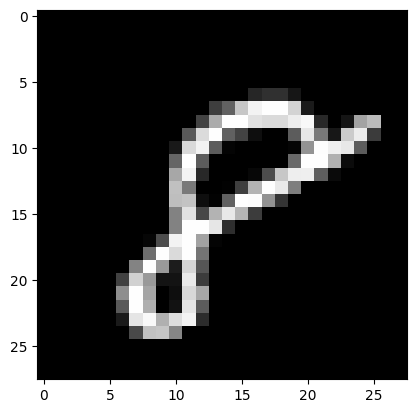

In [3]:
(X_train, Y_train), (X_val, Y_val) = datasets.mnist.load_data()

#visualizando uma imagem de treino (mnist possui o fundo preto e o digito branco)
image = X_train[59999]
plt.imshow(image, cmap='gray')

### **4 - Pré-processamento dos dados**

In [4]:
# Conversão de tipo (boa prática)
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')

# Normalização (dividir os pixels das imagens por 255 -> Deixar entre 0 e 1)
X_train /= 255.0
X_val /= 255.0

# Converter os rótulos (Y), que normalmente estao representado por valores inteiros, para uma matriz de classes binárias (One-Hot Encoding)
# A representação binária evita ordens numéricas falsas entre as categorias e permite comparar diretamente a saída da rede com o gabarito real
Y_train = utils.to_categorical(Y_train)
Y_val =  utils.to_categorical(Y_val)

### **5 - Construindo o modelo da Rede Neural**

In [5]:
# numero de classes (digitos 0 a 9)
num_classes = 10

# Model Sequential permite que construa uma rede neural empilhando camadas, onde a saída de uma camada se torna automaticamente a entrada da próxima
model = models.Sequential()

# Passar o formato das imagens de entrada: shape(altura, largura, canais de cor)
model.add(layers.Input(shape=(28,28,1)))

# Primeira Convolução: Extrai características básicas (bordas, linhas)
# Camada de convulução Conv2D (Bidimensional), indica que a janela de convolução (o kernel) desliza em 2 direções: horizontal e vertical sobre a imagem. Extrai características da imagem, cada filtro gera um mapa de características/features
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), activation='relu')) # usa a função relu, em teoria é a mais apropriada para as camada ocultas da rede

# Camada de pooling (agregação), para redução de dimensionalidade dos mapas de características
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Segunda Convolução: Extrai características complexas (curvas, formatos do número). Utilizou-se mais filtros para compensar a redução de dimensionalidade (perda de pixels/resolução) feita pela camada de pooling anterior
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), activation='relu'))

# Segundo Pooling
model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Camada de achatamento/flatten, responsável por transformar a saída multidimensional da camada de pooling em um vetor unidimensional que será a entrada para as camadas densas (fully connected).
# Ter mais camadas de Conv e Pooling reduzem o tamanho do flatten, o que ajuda a eliminar o vício do modelo (overfitting) e reduzir drasticamente o uso de memória RAM/Processamento
model.add(layers.Flatten())

# Camada densa oculta: aprende padrões a partir das características extraídas pelas camadas convolucionais
model.add(layers.Dense(units=128, activation='relu')) # nesse caso a camada densa oculta terá 128 neurônios

# Camada para evitar overfitting (sobreajuste), que é quando o modelo vai muito bem somente nos dados de treino, mas não na validação/teste, não consegue generalizar bem
model.add(layers.Dropout(0.3)) # Desativa aleatoriamente 30% dos neurônios durante o treinamento, evitando que a rede fique excessivamente dependente de neurônios específicos.

# Mais uma camada densa oculta: aprende representações ainda mais refinadas a partir da saída da camada anterior
model.add(layers.Dense(units=64, activation='relu'))

# Camada densa final/saída: produz a classificação/previsão
model.add(layers.Dense(units=num_classes, activation='softmax', name='predict')) # Em problemas de classificação multiclasse, a quantidade de neurônios da camada de saída deve ser igual à quantidade de classes, pois cada neurônio representa a probabilidade da entrada pertencer a uma determinada classe após a aplicação da função softmax.

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predict (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

###**6 - Treinando o modelo**
Nesse caso utilizou-se os seguintes parâmetros:
* **Função de perda (loss function)/Erro**: Entropia Cruzada Categórica (Categorical Cross-Entropy) que é uma função de perda (loss function) amplamente utilizada em aprendizado de máquina para problemas de classificação multiclasse. Ela mede a diferença (distância) entre a distribuição de probabilidade prevista pelo modelo e a distribuição de probabilidade real (rótulos/labels) para cada classe. Penaliza fortemente o modelo quando ele prevê uma probabilidade baixa para a classe correta e uma probabilidade alta para uma classe incorreta. Quanto menor a perda/erro (mais próximo de zero), melhor o modelo.

* **Otimizador (optimizer)**: Adam (Adaptive Moment Estimation, em português, Estimação Adaptativa de Momentos). Como funciona: Ele adapta a taxa de aprendizado (learning rate) de forma individual para cada peso da rede neural ao longo do treino e estima dois momentos estatísticos dos gradientes para guiar os ajustes: a média (1º momento) e a variância (2º momento). Em termos simples, o Adam aplica a correção baseada no que o backpropagation (alg. responsável pelo cáculo dos gradientes (a direção do erro) e responsabilidade de cada neurônio nesse erro) descobriu.

* **Métricas (Metrics)**: Define as métricas para avaliar e monitorar o desempenho do modelo durante o treinamento e a validação.

* **Sinergia Adam + Entropia Cruzada Categórica**: Quando combina-se o otimizador Adam com a função de perda Entropia Cruzada Categórica, obtém-se uma das combinações mais poderosas da Inteligência Artificial moderna: A Entropia Cruzada Categórica penaliza fortemente os erros de classificação na camada Softmax, enquanto o Adam recebe essa penalização e calcula exatamente o tamanho ideal do passo que cada peso da rede precisa dar para corrigir o erro rapidamente, sem desestabilizar o modelo.

In [6]:
# Configuração dos parâmetros de compilação
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Configurar o EarlyStopping para parar se o val_loss (perda/erro nos dados de validação) parar de melhorar
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3, # Aguarda 3 épocas sem melhora antes de parar
    verbose=1, # mostrar informações
    restore_best_weights=True # Garante que o modelo final terá os pesos da melhor época
)

# Configura o ModelCheckpoint para salvar o arquivo físico do melhor modelo
checkpoint = ModelCheckpoint(
    filepath='melhor_modelo.keras',
    monitor='val_loss',
    save_best_only=True, # Só substitui o arquivo se o val_loss diminuir
)

# Treino do modelo
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=200, # qtd. de amostras que modelo processa antes de atualizar os pesos
    epochs=20, # são os ciclos completos de treinamento da rede neural
    callbacks=[early_stop, checkpoint]
)



Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9030 - loss: 0.3151 - val_accuracy: 0.9771 - val_loss: 0.0705
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9743 - loss: 0.0835 - val_accuracy: 0.9858 - val_loss: 0.0435
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9818 - loss: 0.0604 - val_accuracy: 0.9885 - val_loss: 0.0322
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9853 - loss: 0.0491 - val_accuracy: 0.9895 - val_loss: 0.0326
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9876 - loss: 0.0405 - val_accuracy: 0.9906 - val_loss: 0.0285
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9889 - loss: 0.0348 - val_accuracy: 0.9908 - val_loss: 0.0274
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.9916 - val_loss: 0.0264
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9914 - loss: 0.0269 - val_accuracy: 0

z

O objeto `history` é um objeto tipo dicionário que armazena as seguintes métricas para cada época:

*   `'accuracy'`: A acurácia de treinamento.
*   `'loss'`: A perda de treinamento.
*   `'val_accuracy'`: A acurácia de validação.
*   `'val_loss'`: A perda de validação.

Assim, `history.history['accuracy']` acessa a lista de valores de acurácia registrada durante o treinamento para cada época, e `history.history['val_accuracy']` acessa a acurácia de validação, e o mesmo ocorre para a perda.

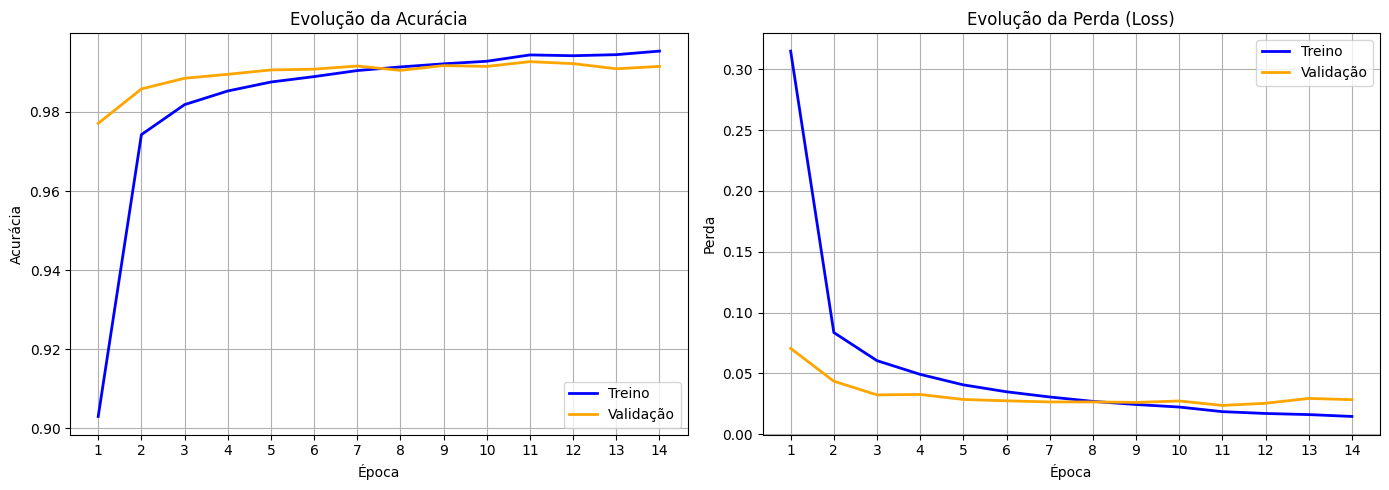

In [7]:
# Descobre quantas épocas foram executadas de verdade (útil caso o EarlyStopping pare antes)
total_epocas = len(history.history['accuracy'])
# Cria uma lista de 1 até o total de épocas executadas
eixos_epocas = range(1, total_epocas + 1)

# Cria a janela para os gráficos
plt.figure(figsize=(14, 5))

# --- GRÁFICO 1: ACURÁCIA ---
plt.subplot(1, 2, 1)
# Passamos 'eixos_epocas' como o primeiro argumento para forçar o início no 1
plt.plot(eixos_epocas, history.history['accuracy'], label='Treino', color='blue', linewidth=2)
plt.plot(eixos_epocas, history.history['val_accuracy'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.xticks(eixos_epocas) # Força o Matplotlib a exibir os números inteiros das épocas no eixo X
plt.legend()
plt.grid(True)

# --- GRÁFICO 2: PERDA (Loss) ---
plt.subplot(1, 2, 2)
# Passamos 'eixos_epocas' como o primeiro argumento aqui também
plt.plot(eixos_epocas, history.history['loss'], label='Treino', color='blue', linewidth=2)
plt.plot(eixos_epocas, history.history['val_loss'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.xticks(eixos_epocas) # Força o Matplotlib a exibir os números inteiros das épocas no eixo X
plt.legend()
plt.grid(True)

# Mostra os gráficos na tela
plt.tight_layout()
plt.show()


### 8 - Testando a rede treinada com uma imagem que não pertence ao dataset

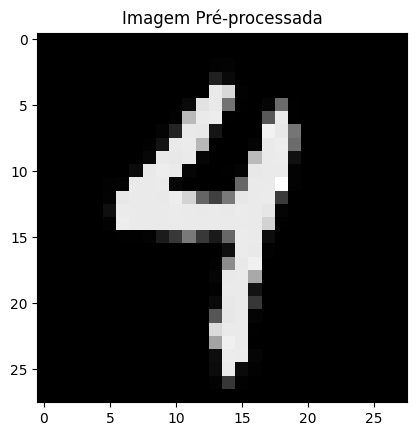

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predição da Classe: 4

Probabilidades de cada classe:
Classe 0: 0.000
Classe 1: 0.000
Classe 2: 0.000
Classe 3: 0.000
Classe 4: 1.000
Classe 5: 0.000
Classe 6: 0.000
Classe 7: 0.000
Classe 8: 0.000
Classe 9: 0.000


In [15]:
# Carrega a imagem em tons de cinza (parametro 0)
img_predicao = cv2.imread('Digito.png', 0)

# Redimensiona para 28x28 caso necessário
if img_predicao.shape != (28,28):
    img_predicao = cv2.resize(img_predicao, (28,28))

# Verifica se a imagem possui fundo branco, se possuir, inverte para o padrão do MNIST: fundo preto e dígito branco
# Se a média de pixels for maior que 127 (255/2), siginifica que o fundo é branco
if np.mean(img_predicao) > 127:
    img_predicao = cv2.bitwise_not(img_predicao)

# Normaliza os pixels para o intervalo de 0.0 até 1.0
img_predicao = img_predicao.astype('float32') / 255.0

# Exibe a imagem após o pré-processamento
plt.imshow(img_predicao, cmap='gray')
plt.title('Imagem Pré-processada')
plt.show()

# Ajusta o formato para o padrão esperado pela CNN: (quantidade_imagens/lote, altura, largura, canais) -> array numpy de 4 dimensões
img_predicao = img_predicao.reshape(1, 28, 28, 1)

# Realiza a predição
# retorna um a lista (array numpy) de probabilidades onde cada indice representa uma classe (0 a 9 nesse caso) bem como sua probabilidade de pertencer a essa classe de acordo com a imagem de entrada
probabilidade_predicao = model.predict(img_predicao)

# Obtém a classe com maior probabilidade (retorna o índice do maior valor, que corresponde a classe prevista)
pred = np.argmax(probabilidade_predicao, axis=-1)

# Exibe a classe prevista
print(f'Predição da Classe: {pred[0]}')

# probabilidade_predicao[0] corresponde às probabilidades da primeira imagem, pois o Keras trabalha em lotes/batches, mesmo que haja apenas uma imagem de entrada
print('\nProbabilidades de cada classe:')
for i, prob in enumerate(probabilidade_predicao[0]):
    print(f'Classe {i}: {prob:.3f}')